#NYS Division of Criminal Justice Services Crime Clearance Investigation



Nicholas Ochs, Jonathan Zheng, Ayron Thomas, Nicholas Gutin



##Introduction



Our team, a group of data analysts, and criminology researchers, has been hired by the New York State Department of Criminal Justice Services ([NYS Division of Criminal Justice Services](https://https://www.criminaljustice.ny.gov/)) to evaluate the crime clearance rate trends across the state. Our goal is to dig deeper into these valuable insights, and understand how effectively reported crimes are being resolved over time, and to assess the various factors that have an influence over the final clearance outcomes. We will attempt to  investigate crime clearance data to be able to inform the [NYS Division of Criminal Justice Services](https://www.criminaljustice.ny.gov/) of any notable trends that we may find in order to enhance public safety, resource allocation, and to curate more effective law enforcement strategies.





# Dataset

The dataset that we will be working with was compiled by the head of Princetons Police Reform Project, and published by the Marhsal Project, which is a nonprofit news organization that seeks to create, and sustain a sense of national urgency about the U.S. criminal justice system. The dataset consists of the following attributes

```
ori: Originating Agency Identifier for law enforcement agencies (categorical)

agency_name: Name of the law enforcement agency that reported the data.(categorical)

state: State the agency is located.(categorical)

year: Reporting year. (categorical)

fips_state_county_code: Six-digit FIPS code for the county that the reporting agency is in. One county can have multiple law enforcement agencies. (categorical)

number_of_months_missing: Some law enforcement agencies only report their data to the FBI for a number of months out of the year. If the value of this field is 0, it means there's no missing data for the year. But if, for example, the value is 6, that means the law enforcement agency only reported six-months worth of data to the FBI. (numerical)

new_{crime}: Number of new crimes that were reported to the police. (numerical)

cleared_{crime}: Number of crimes that police solved in the calendar year, which can include crimes that took place in previous years.(numerical)

clearance_rate_{crime}: The number of cleared crimes divided by the number of new crimes.(numerical)
```

We will leverage correlation and regression analysis to come to our conclusions regarding:

## Research questions:

1. How does the clearance rate in the US compare to the clearance rate in New York state over time?

2. What is the clearance rate for violent vs non-violent crimes in New York state over time, and how are the two rates correlated across counties?

3. What can factors unrelated to violent crimes tell us about violent crime clearance rate?

4. Do additional officers improve a county's clearance rate?   

##Loading Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz
from sklearn.metrics import mean_absolute_error

In [ ]:
cc = pd.read_csv("https://media.githubusercontent.com/media/themarshallproject/crime-clearance-rate/refs/heads/main/crime_clearance_rate.csv")

In [ ]:
cc.head(10)

,ori,agency_name,state,year,fips_state_county_code,number_of_months_missing,new_murder,new_manslaughter,new_rape,new_robbery,...,clearance_rate_rape,clearance_rate_robbery,clearance_rate_assault,clearance_rate_burglary,clearance_rate_theft,clearance_rate_motor_vehicle_theft,clearance_rate_arson,clearance_rate_violent_crime,clearance_rate_property_crime,clearance_rate_total_crime
0,AK00101,anchorage,alaska,2020,2020.0,0,18,0,558,558,...,8.243728,37.096774,58.975247,16.412742,11.883500,17.145344,36.986301,49.279954,13.333333,22.635462
1,AK00101,anchorage,alaska,2019,2020.0,0,32,3,540,621,...,11.481481,31.561997,60.251436,17.021277,12.436380,17.504899,30.107527,48.645630,13.825482,21.650455
2,AK00101,anchorage,alaska,2018,2020.0,0,26,2,613,717,...,20.065253,38.493724,59.183983,15.038685,13.739735,16.330145,34.482759,50.758368,14.515124,22.100597
3,AK00101,anchorage,alaska,2017,2020.0,0,27,3,391,778,...,14.833760,27.763496,55.459057,11.281588,12.666729,16.011598,22.580645,46.296296,13.159039,19.164082
4,AK00101,anchorage,alaska,2016,2020.0,0,28,5,542,695,...,14.760148,29.496403,52.331443,10.408367,13.973016,16.552400,27.536232,44.213910,13.908140,19.625138
5,AK00101,anchorage,alaska,2015,2020.0,0,26,0,517,621,...,13.346228,34.299517,52.600344,9.970326,17.886632,18.544194,28.301887,44.792312,16.922819,22.863940
6,AK00101,anchorage,alaska,2014,2020.0,0,12,3,392,496,...,19.897959,31.451613,55.840307,9.672727,18.585223,15.228967,23.456790,49.059501,17.292456,23.113174
7,AK00101,anchorage,alaska,2013,2020.0,0,14,2,408,522,...,21.323529,31.800766,62.018592,10.622155,22.549518,20.943613,20.270270,50.349076,21.121758,26.016092
8,AK00101,anchorage,alaska,2012,2020.0,0,15,1,303,488,...,25.412541,28.688525,60.743802,12.694301,21.837737,20.216606,24.742268,53.892699,20.742481,27.006632
9,AK00101,anchorage,alaska,2011,2020.0,0,12,1,283,465,...,24.734982,33.118280,61.704583,13.055556,22.025806,20.160000,20.634921,51.926298,20.874648,27.069931


##Data At First Glance

In [ ]:
cc.columns

Index(['ori', 'agency_name', 'state', 'year', 'fips_state_county_code',
       'number_of_months_missing', 'new_murder', 'new_manslaughter',
       'new_rape', 'new_robbery', 'new_assault', 'new_burglary', 'new_theft',
       'new_motor_vehicle_theft', 'new_arson', 'new_violent_crime',
       'new_property_crime', 'new_total_crime', 'cleared_murder',
       'cleared_manslaughter', 'cleared_rape', 'cleared_robbery',
       'cleared_assault', 'cleared_burglary', 'cleared_theft',
       'cleared_motor_vehicle_theft', 'cleared_arson', 'cleared_violent_crime',
       'cleared_property_crime', 'cleared_total_crime',
       'clearance_rate_murder', 'clearance_rate_manslaughter',
       'clearance_rate_rape', 'clearance_rate_robbery',
       'clearance_rate_assault', 'clearance_rate_burglary',
       'clearance_rate_theft', 'clearance_rate_motor_vehicle_theft',
       'clearance_rate_arson', 'clearance_rate_violent_crime',
       'clearance_rate_property_crime', 'clearance_rate_total_crime'],


In [ ]:
ncc = cc.drop(columns = ['cleared_murder',
       'cleared_manslaughter', 'cleared_rape', 'cleared_robbery',
       'cleared_assault', 'cleared_burglary', 'cleared_theft',
       'cleared_motor_vehicle_theft', 'cleared_arson', 'cleared_violent_crime',
       'cleared_property_crime', 'cleared_total_crime'])

In [ ]:
ncc.head()

,ori,agency_name,state,year,fips_state_county_code,number_of_months_missing,new_murder,new_manslaughter,new_rape,new_robbery,...,clearance_rate_rape,clearance_rate_robbery,clearance_rate_assault,clearance_rate_burglary,clearance_rate_theft,clearance_rate_motor_vehicle_theft,clearance_rate_arson,clearance_rate_violent_crime,clearance_rate_property_crime,clearance_rate_total_crime
0,AK00101,anchorage,alaska,2020,2020.0,0,18,0,558,558,...,8.243728,37.096774,58.975247,16.412742,11.883500,17.145344,36.986301,49.279954,13.333333,22.635462
1,AK00101,anchorage,alaska,2019,2020.0,0,32,3,540,621,...,11.481481,31.561997,60.251436,17.021277,12.436380,17.504899,30.107527,48.645630,13.825482,21.650455
2,AK00101,anchorage,alaska,2018,2020.0,0,26,2,613,717,...,20.065253,38.493724,59.183983,15.038685,13.739735,16.330145,34.482759,50.758368,14.515124,22.100597
3,AK00101,anchorage,alaska,2017,2020.0,0,27,3,391,778,...,14.833760,27.763496,55.459057,11.281588,12.666729,16.011598,22.580645,46.296296,13.159039,19.164082
4,AK00101,anchorage,alaska,2016,2020.0,0,28,5,542,695,...,14.760148,29.496403,52.331443,10.408367,13.973016,16.552400,27.536232,44.213910,13.908140,19.625138


###Attributes

In [ ]:
ncc.columns
ncc.isna().sum()

,0
ori,0
agency_name,0
state,684
year,0
fips_state_county_code,13149
number_of_months_missing,0
new_murder,0
new_manslaughter,0
new_rape,0
new_robbery,0


In [ ]:
ncc_copy = ncc.dropna()
ncc_copy.isna().sum()

,0
ori,0
agency_name,0
state,0
year,0
fips_state_county_code,0
number_of_months_missing,0
new_murder,0
new_manslaughter,0
new_rape,0
new_robbery,0


### Research Question 1
This question aims to provide us with the essential background information needed to conduct research for our division. Finding the overall clearance rate in the US, and comparing it to the clearance rate in New York will set us up with a basic foundation of how we must begin to improve our law enforcement effectiveness, and will also give us an idea of where we are at in comparison to the rest of the country.

When we look at violent crime clearance rates over time, New York generally performs close to and even above national average. While the U.S. average remains fairly steady over the years, New York shows similar trends but at a higher volume until 2010. After 2010, New York’s data became a lot more volatile, with sharp spikes and dips.

Texas and New York are both large states, but they differ in some key ways. While New York is home to NYC, a highly dense metropolis with a population of 8.2 million, Texas, despite having a larger overall population, doesn't have a city that compares in terms of population density. The most densely populated city in Texas is Houston, with 2.3 million residents, which is far fewer than New York City’s. Looking at the data, we see that Texas generally has lower but more consistent crime clearance rates compared to New York, which shows more fluctuation. This could be attributed to a variety of factors, but one key point is the way the population is spread out in Texas. Unlike New York, which has a high concentration of their population in NYC, Texas's larger, more rural areas may lead to a different allocation of resources. New York has historically invested more aggressively in crime prevention, which could be a result of the unique challenges posed by having a densely populated city like NYC. In contrast, Texas's approach may be shaped by its need to address crime prevention and response across a broader geographic area.

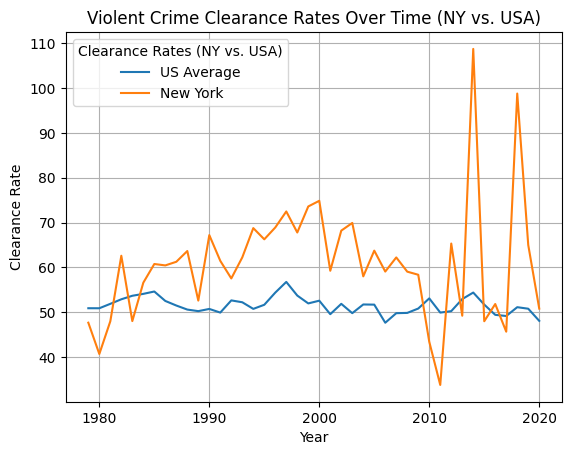

In [ ]:
us_avg = ncc_copy.groupby('year')['clearance_rate_violent_crime'].mean().reset_index()
ny_avg = ncc_copy[ncc_copy['state'] == 'new york'].groupby('year')['clearance_rate_violent_crime'].mean().reset_index()

sns.lineplot(x=us_avg['year'], y=us_avg['clearance_rate_violent_crime'], label='US Average')
sns.lineplot(x=ny_avg['year'], y=ny_avg['clearance_rate_violent_crime'], label='New York')

plt.title('Violent Crime Clearance Rates Over Time (NY vs. USA)')
plt.xlabel('Year')
plt.ylabel('Clearance Rate')
plt.grid(True)
plt.legend(title= 'Clearance Rates (NY vs. USA)')
plt.show()

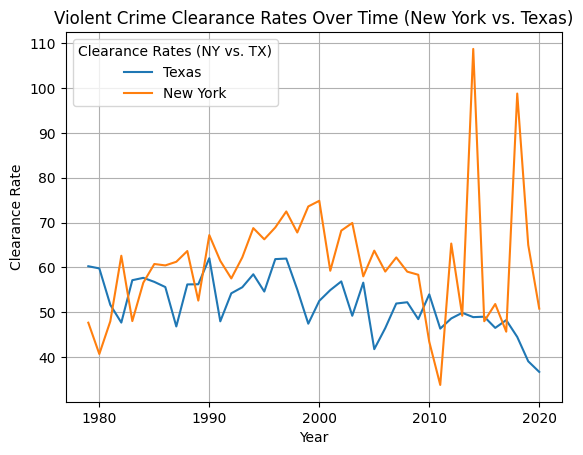

In [ ]:
tx_avg = ncc_copy[ncc_copy['state'] == 'texas'].groupby('year')['clearance_rate_violent_crime'].mean().reset_index()
ny_avg = ncc_copy[ncc_copy['state'] == 'new york'].groupby('year')['clearance_rate_violent_crime'].mean().reset_index()
sns.lineplot(x=tx_avg['year'], y=tx_avg['clearance_rate_violent_crime'], label='Texas')
sns.lineplot(x=ny_avg['year'], y=ny_avg['clearance_rate_violent_crime'], label='New York')

plt.title('Violent Crime Clearance Rates Over Time (New York vs. Texas)')
plt.xlabel('Year')
plt.ylabel('Clearance Rate')
plt.grid(True)
plt.legend(title= 'Clearance Rates (NY vs. TX)')
plt.show()

#Research Question 2
This question addresses the measure of law enforcement effectiveness between violent, and non-violent crimes in New York State. Non-violent crimes in this dataset are recognized under four categories, which are burglary, theft, motorvehicle theft, and arson. The importance of distinguishing between these two sectors of crime is because they generally demand different investigative resources. After finding this information, we will be able to provide the (NYSDCJS) with the proper knowledge to allocate the correct amount of resources to each respective county.

Understanding the difference in clearance rates across different types of crime isn't just a matter of tracking performance, but it is more about justice, resource allocation, public trust/safety, and upholding institutional credibility of law enforcement agencies.

We hypothesize that having a higher clearance rate for both violent, and non-violent crimes suggests that there is a positive correlation between the two. For the counties whose data contradicts our hypothesis; they may be in need of more resources to conduct investigative processes. The data supports our hypothesis that there is a positive correlation between both clearance rates, because they generally rise and fall together. The data suggests an unusual spike around the mid 2010’s suggesting a possible change in reporting, or policy.


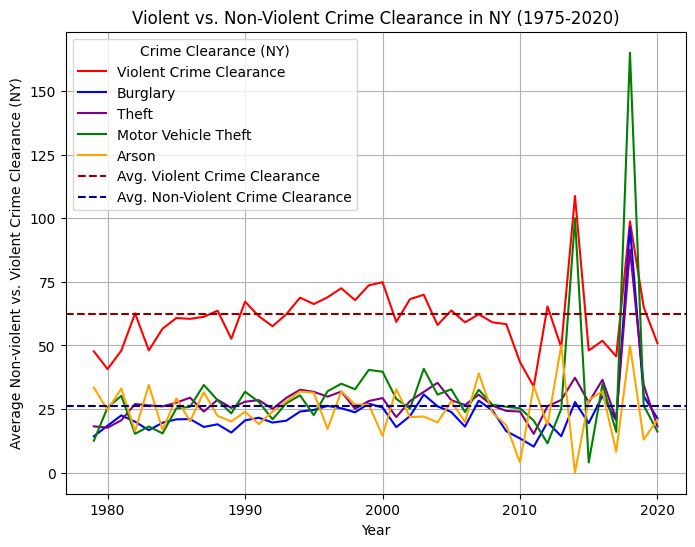

In [ ]:
ncc["clearance_rate_nonviolent"] = ncc[["clearance_rate_burglary", "clearance_rate_theft","clearance_rate_motor_vehicle_theft", "clearance_rate_arson"]].mean(axis=1)
nyncc= ncc[ncc['state'] == 'new york']
nyncc= nyncc.dropna()
nyncc

plt.figure(figsize=(8, 6))

sns.lineplot(x=nyncc['year'], y=nyncc['clearance_rate_violent_crime'], label='Violent Crime Clearance', color='red', errorbar=None)

sns.lineplot(x=nyncc['year'], y=nyncc['clearance_rate_burglary'], label='Burglary', color = 'blue', errorbar=None)
sns.lineplot(x=nyncc['year'], y=nyncc['clearance_rate_theft'], label='Theft', color = 'purple', errorbar=None)
sns.lineplot(x=nyncc['year'], y=nyncc['clearance_rate_motor_vehicle_theft'], label='Motor Vehicle Theft', color = 'green', errorbar=None)
sns.lineplot(x=nyncc['year'], y=nyncc['clearance_rate_arson'], label='Arson', color = 'orange', errorbar=None)

violent_avg = nyncc['clearance_rate_violent_crime'].mean()
nonviolent_avg = nyncc['clearance_rate_nonviolent'].mean()

plt.axhline(y=violent_avg, color='darkred', linestyle='--', linewidth=1.5, label='Avg. Violent Crime Clearance')
plt.axhline(y=nonviolent_avg, color='darkblue', linestyle='--', linewidth=1.5, label='Avg. Non-Violent Crime Clearance')

plt.ylabel('Average Non-violent vs. Violent Crime Clearance (NY)')
plt.xlabel('Year')
plt.grid()


plt.title('Violent vs. Non-Violent Crime Clearance in NY (1975-2020)')
plt.legend(title = "Crime Clearance (NY)")

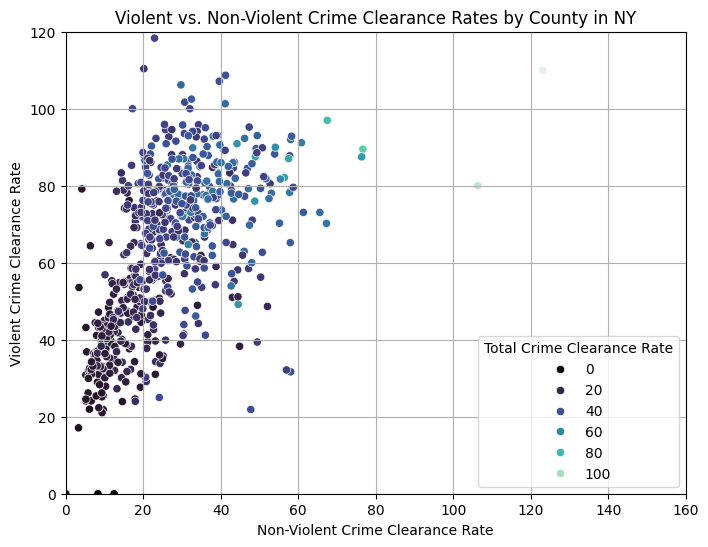

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=nyncc, x='clearance_rate_nonviolent', y='clearance_rate_violent_crime', hue="clearance_rate_total_crime", palette="mako")
plt.xlim(0, 160)
plt.ylim(0, 120)
plt.legend(title="Total Crime Clearance Rate")
plt.xlabel('Non-Violent Crime Clearance Rate')
plt.ylabel('Violent Crime Clearance Rate')
plt.title('Violent vs. Non-Violent Crime Clearance Rates by County in NY')
plt.grid(True)




#Research Question 3
This question makes us think about the effects variables that are unrelated to violent crimes have on the violent crime clearance rate. This is important because we can see the significance of these variables as well as how you could use them to infer information about the violent crime clearance rate. I woulld hypothesize that the clearance rate  of thes non-violent crimes would have a positive correlation wtih the clearance rate of violent crimes.

In [ ]:
nyncc= ncc[ncc['state'] == 'new york']
nyncc= nyncc.dropna()
nyncc

Y = nyncc['clearance_rate_violent_crime']
X = nyncc[['clearance_rate_property_crime','number_of_months_missing', 'clearance_rate_motor_vehicle_theft', 'clearance_rate_theft','clearance_rate_arson']]
X = pd.get_dummies(X, drop_first=True).astype("float32")
X = sm.tools.tools.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                                 OLS Regression Results                                 
Dep. Variable:     clearance_rate_violent_crime   R-squared:                       0.435
Model:                                      OLS   Adj. R-squared:                  0.430
Method:                           Least Squares   F-statistic:                     93.97
Date:                          Mon, 01 Dec 2025   Prob (F-statistic):           2.45e-73
Time:                                  14:48:52   Log-Likelihood:                -2592.5
No. Observations:                           617   AIC:                             5197.
Df Residuals:                               611   BIC:                             5224.
Df Model:                                     5                                         
Covariance Type:                      nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
-------

By looking at the standard deviation of our model, which is 16.2, we can see that using a linear regression model may not be the most efficient model as well our R-squared also being very low. Through this standard deviation we see that our model can be unaccurate up to a large margin of percent, around 16.2 so we should explore another option, particulalry being a random forest model.

In [ ]:
nyncc= ncc[ncc['state'] == 'new york']
nyncc= nyncc.dropna()
nyncc

Y = nyncc['clearance_rate_violent_crime']
X = nyncc[['clearance_rate_property_crime', 'number_of_months_missing', 'clearance_rate_motor_vehicle_theft', 'clearance_rate_theft','clearance_rate_arson']]
X = pd.get_dummies(X, drop_first=True).astype("float32")
X = sm.tools.tools.add_constant(X)
feature_names = X.columns.tolist()

In [ ]:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=314159)

In [ ]:
model = RandomForestRegressor().fit(X_train, Y_train)

In [ ]:
Y_pred = model.predict(X_test)

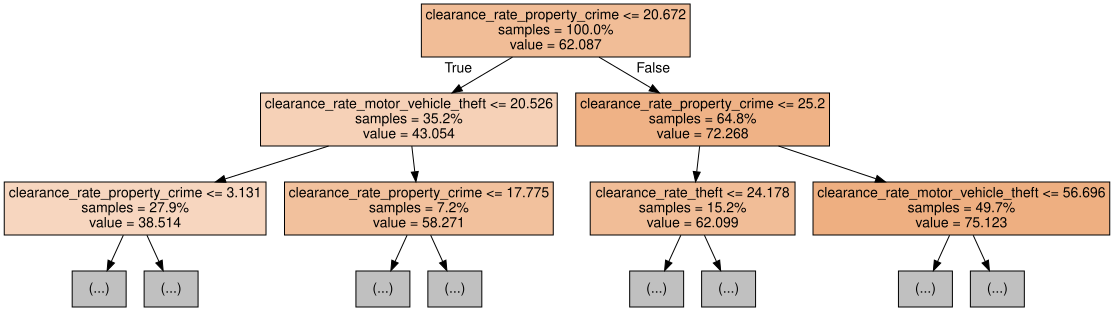

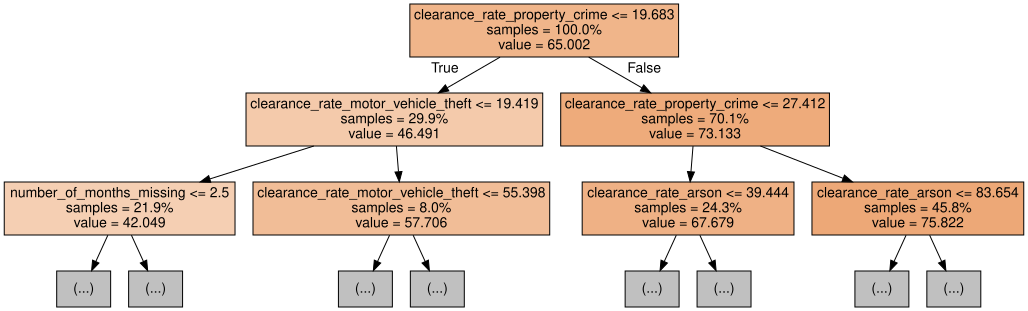

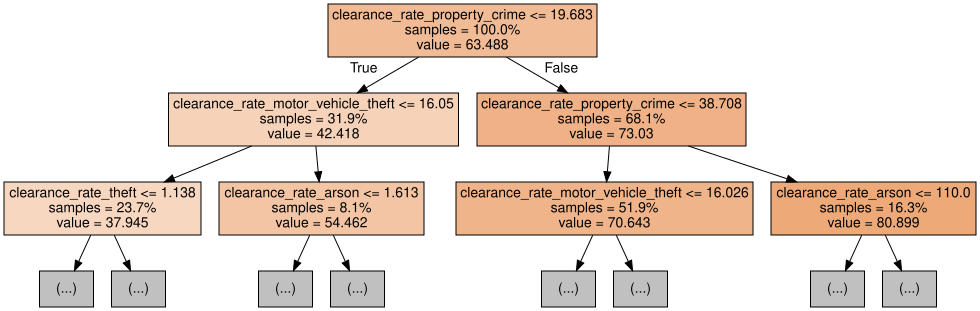

In [ ]:
#Example Trees
for i in range(3):
    tree = model.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

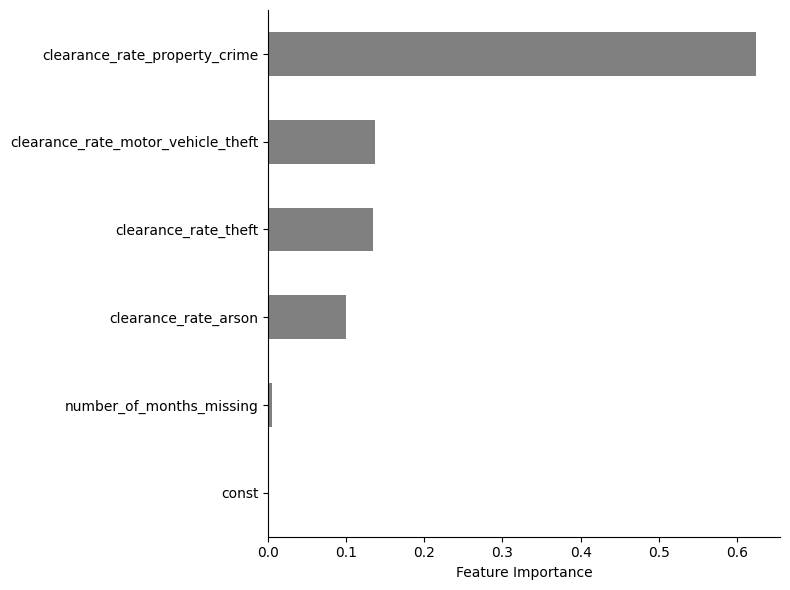

In [ ]:
forest_importances = pd.Series(model.feature_importances_,index=feature_names)
forest_importances.sort_values(inplace=True, ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
forest_importances.plot.barh(ax=ax, color='grey')
ax.set_xlabel("Feature Importance")


ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

fig.tight_layout()

In [ ]:
mae = mean_absolute_error(Y_test, Y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 10.156309613502092


This mean absolute error is not terrible but not the best either which shows that perhaps a Ranodm Forest model isn't the most effectiove appropriate model either or potentially the correlation between the dependent and independent facors isn't strong enough to reach a conclusion. But from the feature importance graph we can see how the most significant tool we could use to judge violent crime clearance rate is the theft for clearance rate

##Research Question 4


### Discussion

To investigate whether increasing police officer staffing improves crime clearance rates at the county level in New York State, the fundamental policy question that needs to be answered is whether additional law enforcement resources translate into more effective crime solving. To answer this, I employed OLS regression with log-transformed cleared crimes as the dependent variable to avoid mechanical correlation issues inherent in using clearance rates directly. To further prevent correlation issues, officers-per-crime ratios were used rather than raw employment figures to address multicollinearity and better capture resource allocation intensity(essentially representing coverage by police force). The square of this varriable was also added to capture any diminishing returns with officer employment and clearance rates.

The final model chosen for estimation was:

 log(total_cleared) = β₀ + β₁(new_total_crime) + β₂(officers_per_crime) + β₃(officers_per_crime²) + controls



Basic analysis of officer per crime coefficient reveals a negative relationship, suggesting a 1% increase in officer to crime ratio leads to an 8.5% decrease in total clearance. More rigorous analysis revealed a surprising U-shaped relationship between officer coverage and clearance effectiveness. While the quadratic term wasn't individually significant (p=0.051), joint significance F-tests confirmed a non-linear relationship between officer coverage and clearance rates. Residual analysis and mean residual also suggest that the model shouldn't suffer from bias (the error mean independence assumption should be achieved). Before conducting hypothesis testing, a Breusch-Pagan test was conducted to check for heteroskedasticity, which revealed a heteroskedasticity problem. Robust SEs were computed to fix this.


However, to see and test the effectiveness of ADDITIONAL officers, analysis and testing of the marginal effect of additional officer coverage on clearance rates is required. This marginal effect can be represented by:

 ∂log(total_cleared)/∂(officers_per_crime) = β₂ + 2β₃(officers_per_crime)



To test whether marginal increases in police force helped with clearance rates, the marginal effect of the average county police size (and its SE) is calculated, and the following hypothesis test is drawn:

 H₀: β₂ + 2β₃(mean) ≤ 0

 H₁: β₂ + 2β₃(mean) > 0

Using a one-sided t-test reveals that, while the marginal effect is statistically significant, and it's significant in the opposite direction. Meaning the average county in New York gets lower clearance rates when additional officers are hired. However, the u-shape and existence of a critical point all suggest that a benefit DOES exist after an officer-to-crime ratio of over 1.16. The most realistic explanation is that the hiring of generic police officers does not lead to more crimes being solved/cleared and up until hiring a ratio of 1.16 officers-to-crime


## CODE

In [ ]:
'''
The following code is necessary for feature engineering and merging the two data sets
'''


fips = {
  "Albany": 36001,
  "Allegany": 36003,
  "Broome": 36007,
  "Cattaraugus": 36009,
  "Cayuga": 36011,
  "Chautauqua": 36013,
  "Chemung": 36015,
  "Chenango": 36017,
  "Clinton": 36019,
  "Columbia": 36021,
  "Cortland": 36023,
  "Delaware": 36025,
  "Dutchess": 36027,
  "Erie": 36029,
  "Essex": 36031,
  "Franklin": 36033,
  "Fulton": 36035,
  "Genesee": 36037,
  "Greene": 36039,
  "Hamilton": 36041,
  "Herkimer": 36043,
  "Jefferson": 36045,
  "Lewis": 36049,
  "Livingston": 36051,
  "Madison": 36053,
  "Monroe": 36055,
  "Montgomery": 36057,
  "Nassau": 36059,
  "New York City": 36061,
  "Niagara": 36063,
  "Oneida": 36065,
  "Onondaga": 36067,
  "Ontario": 36069,
  "Orange": 36071,
  "Orleans": 36073,
  "Oswego": 36075,
  "Otsego": 36077,
  "Putnam": 36079,
  "Rensselaer": 36083,
  "Rockland": 36087,
  "Saratoga": 36091,
  "Schenectady": 36093,
  "Schoharie": 36095,
  "Schuyler": 36097,
  "Seneca": 36099,
  "St Lawrence": 36089,
  "Steuben": 36101,
  "Suffolk": 36103,
  "Sullivan": 36105,
  "Tioga": 36107,
  "Tompkins": 36109,
  "Ulster": 36111,
  "Warren": 36113,
  "Washington": 36115,
  "Wayne": 36117,
  "Westchester": 36119,
  "Wyoming": 36121,
  "Yates": 36123
}

nyc_borough_fips = [
    36005,  # Bronx
    36047,  # Brooklyn
    36061,  # Manhattan
    36081,  # Queens
    36085   # Staten Island
]

# Function to convert borough FIPS to the single NYC FIPS
def consolidate_nyc_fips(fips):
    if fips in nyc_borough_fips:
        return 36061
    else:
        return fips

In [ ]:

#fix clearance data
state = cc[cc['state'] == 'new york']
state['fips_state_county_code'] = state['fips_state_county_code'].apply(consolidate_nyc_fips)

clearance_data = state[['ori','fips_state_county_code', 'year', 'new_total_crime', 'cleared_total_crime', 'new_violent_crime' ]]

clearance_data = clearance_data.groupby(['fips_state_county_code', 'year']).agg({
    'new_total_crime': 'sum',
    'cleared_total_crime': 'sum',
    'new_violent_crime' : 'sum'
}).reset_index()

clearance_data = clearance_data[clearance_data['year'] >= 2007]
clearance_data['log_cleared'] = np.log(clearance_data['cleared_total_crime']) #calculate clearance RATE with log instead of ratio to avoid correlation and bias issues

#load police data
path = 'https://raw.githubusercontent.com/ngutin1/dida/refs/heads/main/Law_Enforcement_Personnel_by_Agency___Beginning_2007_20250505.csv'
ny = pd.read_csv(path) #https://data.ny.gov/Public-Safety/Law-Enforcement-Personnel-by-Agency-Beginning-2007/khn9-hhpq/about_data
police_data = ny[['County', 'Year', 'Grand Total']]

police_data = police_data.groupby(['County', 'Year']).agg({
    'Grand Total': 'sum'
}).reset_index()

police_data['fips'] = police_data['County'].map(fips)


#merge two dfs to create training data
clearance_data = clearance_data.rename(columns = {'fips_state_county_code':'fips', 'year':'Year'})
police_data = police_data.rename(columns = {'Grand Total':'officers_employed'})

training = pd.merge(
    clearance_data,
    police_data,
    on=['fips', 'Year'],
    how='inner'
)


#feature creation
training['officers_per_crime'] = training['officers_employed'] / (training['new_total_crime'] ) #officer coverage varriable

training['officers_per_crime_sq'] = training['officers_per_crime']**2 #squared coverage var to check for diminishing returns on police coverage

training['violent_crime_ratio'] = training['new_violent_crime'] / training['new_total_crime'] # % of crimes that are violent in county

training['cases_per_officer'] = training['new_total_crime'] / training['officers_employed'] #cases to officers ratio

training


/tmp/ipython-input-68862163.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  state['fips_state_county_code'] = state['fips_state_county_code'].apply(consolidate_nyc_fips)


,fips,Year,new_total_crime,cleared_total_crime,new_violent_crime,log_cleared,County,officers_employed,officers_per_crime,officers_per_crime_sq,violent_crime_ratio,cases_per_officer
0,36001.0,2007,10616.0,2878.0,1464.0,7.964851,Albany,1305,0.122928,0.015111,0.137905,8.134866
1,36001.0,2008,10607.0,2117.0,1324.0,7.657755,Albany,1177,0.110964,0.012313,0.124823,9.011895
2,36001.0,2009,10432.0,2584.0,1288.0,7.857094,Albany,1312,0.125767,0.015817,0.123466,7.951220
3,36001.0,2010,11053.0,2411.0,1185.0,7.787797,Albany,1329,0.120239,0.014457,0.107211,8.316780
4,36001.0,2011,10641.0,1878.0,1166.0,7.537963,Albany,1280,0.120289,0.014470,0.109576,8.313281
...,...,...,...,...,...,...,...,...,...,...,...,...
806,36123.0,2016,320.0,67.0,17.0,4.204693,Yates,69,0.215625,0.046494,0.053125,4.637681
807,36123.0,2017,258.0,56.0,26.0,4.025352,Yates,55,0.213178,0.045445,0.100775,4.690909
808,36123.0,2018,247.0,70.0,17.0,4.248495,Yates,53,0.214575,0.046042,0.068826,4.660377
809,36123.0,2019,187.0,66.0,23.0,4.189655,Yates,52,0.278075,0.077326,0.122995,3.596154


In [ ]:
#check correlation matrix for multi colin issues

corr_mat = training[['log_cleared', 'officers_per_crime', 'officers_per_crime_sq', 'violent_crime_ratio', 'cases_per_officer']].corr()
print(corr_mat)

                       log_cleared  officers_per_crime  officers_per_crime_sq  \
log_cleared               1.000000           -0.256395              -0.233934   
officers_per_crime       -0.256395            1.000000               0.895057   
officers_per_crime_sq    -0.233934            0.895057               1.000000   
violent_crime_ratio       0.238538            0.352109               0.304906   
cases_per_officer         0.159948           -0.678924              -0.414702   

                       violent_crime_ratio  cases_per_officer  
log_cleared                       0.238538           0.159948  
officers_per_crime                0.352109          -0.678924  
officers_per_crime_sq             0.304906          -0.414702  
violent_crime_ratio               1.000000          -0.234136  
cases_per_officer                -0.234136           1.000000  


#### linear regression

In [ ]:
X = training[['new_total_crime','officers_per_crime', 'officers_per_crime_sq', 'violent_crime_ratio', 'cases_per_officer']]
y = training['log_cleared']


X = sm.tools.tools.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_cleared   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.272
Method:                 Least Squares   F-statistic:                     61.50
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           2.50e-54
Time:                        14:48:54   Log-Likelihood:                -1266.0
No. Observations:                 811   AIC:                             2544.
Df Residuals:                     805   BIC:                             2572.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     6.84

#### Inference and Testing

-  inference skills from econometrics + the following new commands:

https://medium.com/@roshmitadey/a-quick-guide-to-statistical-modeling-in-python-usn-df367e80097a


In [ ]:
'''
since officer coverage squared is insignficant on its own, test if model is signfificant with with the both coverage and coverage^2 to see if we can
diminishing
'''

hypothesis = '(officers_per_crime = 0), (officers_per_crime_sq = 0)'
f_test = model.f_test(hypothesis)

print(f"F-statistic: {f_test.fvalue}, p-value: {f_test.pvalue}")

F-statistic: 46.098813865755744, p-value: 1.1101327540211953e-19


In [ ]:
# Test for heteroskedasticity
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(model.resid, X)
print(bp_test[1])

4.934056085918064e-63


In [ ]:
#since heteroskedasticity exists we need to fix SE
#https://stackoverflow.com/questions/30553838/getting-statsmodels-to-use-heteroskedasticity-corrected-standard-errors-in-coeff

model_robust = sm.OLS(y, X).fit(cov_type='HC3')
final_model = model_robust

final_model = model
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_cleared   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.272
Method:                 Least Squares   F-statistic:                     61.50
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           2.50e-54
Time:                        14:48:55   Log-Likelihood:                -1266.0
No. Observations:                 811   AIC:                             2544.
Df Residuals:                     805   BIC:                             2572.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     6.84

2.781717861946138e-13


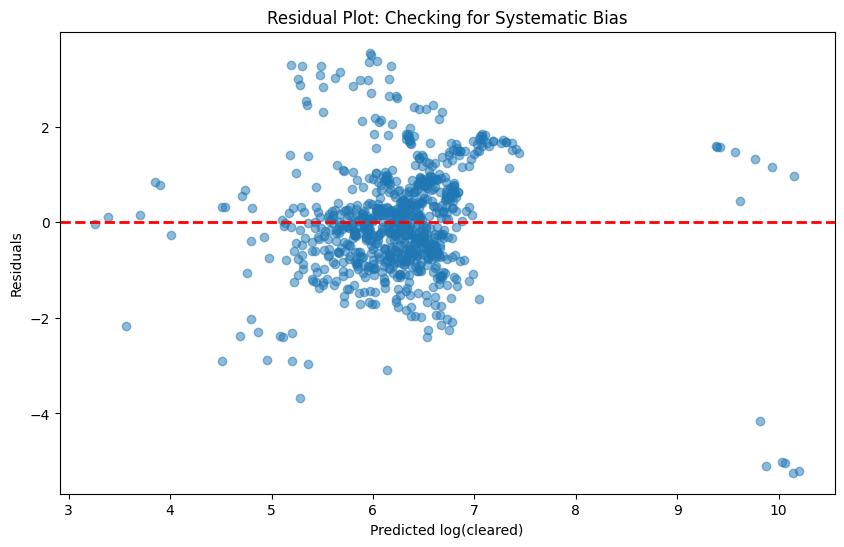

In [ ]:
#residual analysis for bias check

residuals = final_model.resid
predictions = final_model.predict()

mean_residual = residuals.mean()
print(mean_residual)

plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted log(cleared)')
plt.ylabel('Residuals')
plt.title('Residual Plot: Checking for Systematic Bias')
plt.show()


#### Marginal Effect & Hypothesis Testing

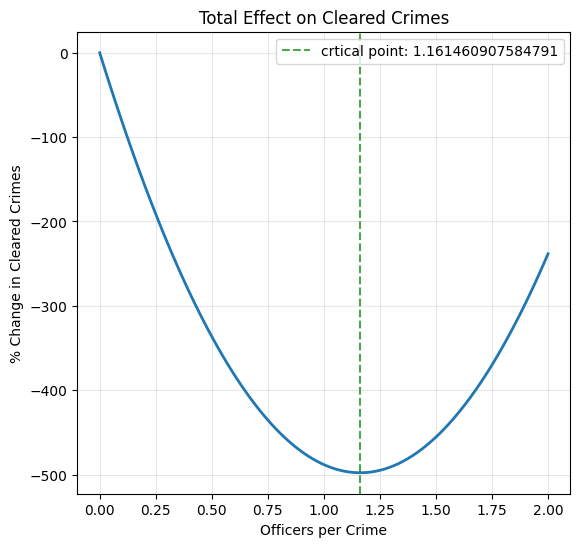

In [ ]:
#marginal effect of officers and critical point:
officer_range = np.linspace(0, 2, 100)
y = (-8.574 * officer_range + 3.691 * officer_range**2)
critical_point = -model.params['officers_per_crime'] / (2 * model.params['officers_per_crime_sq'])

# Find marginal effects
marginal_effect = -8.574 + (2 * 3.691 * officer_range)

plt.figure(figsize=(14, 6))

# visualize the relationship between
plt.subplot(1, 2, 1)
plt.plot(officer_range, y * 100, linewidth=2)
plt.axvline(x=critical_point, color='g', linestyle='--', alpha=0.7, label=f'crtical point: {critical_point}')
plt.xlabel('Officers per Crime')
plt.ylabel('% Change in Cleared Crimes')
plt.title('Total Effect on Cleared Crimes')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
#hypothesis test using mean officers per crime

mean = training['officers_per_crime'].mean()

#robust SE
se_officers = 1.536
se_officers_sq = 1.890

#covariance necessary to calculate the SE of the
cov = model.cov_params().loc['officers_per_crime', 'officers_per_crime_sq']


marginal_effect = -8.574 + (2 * 3.691 * mean)

#https://stats.stackexchange.com/questions/55795/how-to-calculate-the-standard-error-of-the-marginal-effects-in-interactions-rob
var = se_officers**2 + 4 * (mean)**2 * se_officers_sq**2
marginal_se = np.sqrt(var)

t = marginal_effect/marginal_se
print(t)

-4.518751330647464


# Conclusion

Q1.) Our analysis showed that NYC often performed above the national average until 2010 in which the data became more volatile with big spikes and dips from year to year. This could be due to a lot of variables such as how crime and law enforcement priorities changed and their performance. To better understand the reason NYC has such high clearance rates we decided to also analyze Texas as they are both very large and heavily populated states, but they're also very different in how they operate. NYC has a heavily concentrated population in NYC itself, while Texas's population is more spread out across its geography even with its major cities barely scratching NYC's population. We assume that the difference in geography and dispersement of their population sizes likely plays a big role in how each state handles crime.

The data on Texas shows very consistent but lower clearance rates despite having a bigger population than NYC. One reason could be that historically NYC has invested more resources in crime prevention such as the "War on Drugs" during Richard Nixon's administration. NYC's more dense population likely contributes to a more aggressive strategy and take on crime which might explain the high spikes and dips we see after 2010.

I believe the analysis was effective but perhaps if we could also look into data regarding the rural parts of NYC we could reveal more trends and comparisons. If the data set had information on law enforcement like the dispersement of officers across the different boroughs of NYC and Texas it could help provide a more in-depth analysis

 Q2.) The results of this research question revealed a positive association between both violent, and nonviolent crime clearance rates, and it confirmed the difference in the rate at which these crimes cleared across both time, and across various counties in New York, which confirmed our hypothesis of the two variables being positively correlated.

The first half of the question aimed to show the clearance rates in New York across time. What we found was that Violent Crime clearance was consistently above Non-violent crime clearance rate (which includes burglary, theft, motor vehicle theft, and arson), besides an unusual spike in the mid 2010’s. The overall consensus showed an average Violent crime clearance of ~67%, and average Non-violent crime clearance of ~26% over time. The two rates generally moved in unison, which further confirms our hypothesis that there is a positive correlation between the variables.

To test the second half of the research question, which aimed to show the correlation between total crime in counties, we used a gradient scatterplot. The darker points corresponded with a lower clearance rate, whereas the lighter points corresponded with counties who had higher clearance rates. Overall, this further confirms our hypothesis that there is a positive correlation between the two variables across counties as well, and provides the NYSDCJ with the information they need to assess the differences in resources between counties  to potentially test if those crime clearance rates increase as a response to change in certain areas.

While the analysis we ran was able to successfully prove the positive correlation between these two variables, it would potentially be more beneficial to include more sophisticated data that truly tells the story. Variables such as County police funding, population/officer ratios, and other demographic details could potentially have made the research more effective in testing the hypothesis that having higher resource allocation will improve clearance rates.


Q3).

When considering the second research question, two conclusions can be drawn. First, it's important to understand the problem and inherent inaccuracies within the analysis. From our models we would presume that there are correlations between factors like property crime clearance rate, motor theft clearance rate, and violent crime. The linear regression model suggests a positive correlation between these factors, which intuitively makes sense. For example, we can imagine that if a department or county is good at clearing non-violent crimes, they would also likely be good at clearing violent crimes as well. From our random forest model, we can see the importance of these factors in decision-making and assess which factors are more telling. However, all of this must be accepted with caution, as there may be a large amount of variability. We can observe this from both the R-squared value and standard deviation in our linear regression, as well as the MAE in our random forest model. To improve the analysis, I believe we would either need more data to work with, perhaps more non-violent factors to consider, or we might need to consider using a different model altogether.


Q4.)

The analysis revealed a counterintuitive finding that additional police officers do not uniformly improve crime clearance rates in New York counties. The hypothesis test definitively shows that for the average county, hiring more officers actually reduces clearance effectiveness (t = -4.1), challenging the convention that more police equals better outcomes. However, the U-shaped relationship provides critical nuance, while additional officers harm clearance rates in departments below 1.16 officers per crime, they begin helping once this threshold is crossed, suggesting some sort of oppertunity cost presents itself up until theres 1.16 officers per crime. Meaning blanket police hiring may be counterproductive for understaffed departments, which might benefit more from improving efficiency and training, while only departments above the critical threshold should expect clearance improvements from expansion. This research demonstrates that effective policing depends not on raw numbers but on reaching a critical mass necessary for specialized investigative capabilities, highlighting the importance of strategic police staffing decisions when trying to improve county or department clearance rates.